In [23]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib, os, json, subprocess

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42

In [22]:
#Load data

df_raw = pd.read_csv("/content/sample_data/FAOSTAT_data_en_3-12-2026.csv", encoding="utf-8-sig")
print(f"Raw shape: {df_raw.shape}")
print(f"Elements: {df_raw['Element'].unique()}")
print(f"Crops: {len(df_raw['Item'].unique())} unique crops")
print(f"Years: {df_raw['Year'].min()} to {df_raw['Year'].max()}")
df_raw.head()

Raw shape: (5064, 15)
Elements: ['Area harvested' 'Production' 'Yield']
Crops: 35 unique crops
Years: 1961 to 2024


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,1311.0,Avocados,1991,1991,ha,NaN,M,Missing value; data cannot exist,NaN
1,QCL,Crops and livestock products,646,Rwanda,5510,Production,1311.0,Avocados,1991,1991,t,NaN,M,Missing value; data cannot exist,NaN
2,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,1311.0,Avocados,1992,1992,ha,NaN,M,Missing value; data cannot exist,NaN
3,QCL,Crops and livestock products,646,Rwanda,5510,Production,1311.0,Avocados,1992,1992,t,NaN,M,Missing value; data cannot exist,NaN
4,QCL,Crops and livestock products,646,Rwanda,5312,Area harvested,1311.0,Avocados,1993,1993,ha,NaN,M,Missing value; data cannot exist,NaN


In [5]:
#  Explanatory Data analysis
print("=== Missing Values ===")
print(df_raw.isnull().sum())
print("\n=== Flag Distribution ===")
print(df_raw["Flag Description"].value_counts())

=== Missing Values ===
Domain Code            0
Domain                 0
Area Code (M49)        0
Area                   0
Element Code           0
Element                0
Item Code (CPC)        0
Item                   0
Year Code              0
Year                   0
Unit                   0
Value                484
Flag                   0
Flag Description       0
Note                5012
dtype: int64

=== Flag Distribution ===
Flag Description
Official figure                        2182
Estimated value                        1754
Value imputed by a receiving agency     568
Missing value; data cannot exist        484
Figure from external organization        76
Name: count, dtype: int64


In [6]:
#pivot to wide format
df_clean = df_raw[df_raw["Value"].notna() & (df_raw["Flag"] != "M")].copy()

pivot = df_clean.pivot_table(   index=["Area", "Item", "Year"],   columns="Element",   values="Value",aggfunc="first").reset_index()

pivot.columns.name = None
pivot.columns = [c.lower().replace(" ", "_") for c in pivot.columns]
print(f"Pivoted shape: {pivot.shape}")
pivot.head(10)

Pivoted shape: (1593, 6)


,area,item,year,area_harvested,production,yield
0,Rwanda,Avocados,1998,400.0,3000.0,7500.0
1,Rwanda,Avocados,1999,400.0,3500.0,8750.0
2,Rwanda,Avocados,2000,450.0,3500.0,7777.8
3,Rwanda,Avocados,2001,450.0,3500.0,7777.8
4,Rwanda,Avocados,2002,450.0,4000.0,8888.9
5,Rwanda,Avocados,2003,500.0,4000.0,8000.0
6,Rwanda,Avocados,2004,500.0,4000.0,8000.0
7,Rwanda,Avocados,2005,550.0,4500.0,8181.8
8,Rwanda,Avocados,2006,600.0,4500.0,7500.0
9,Rwanda,Avocados,2007,600.0,5000.0,8333.3


/tmp/ipykernel_414/739017191.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


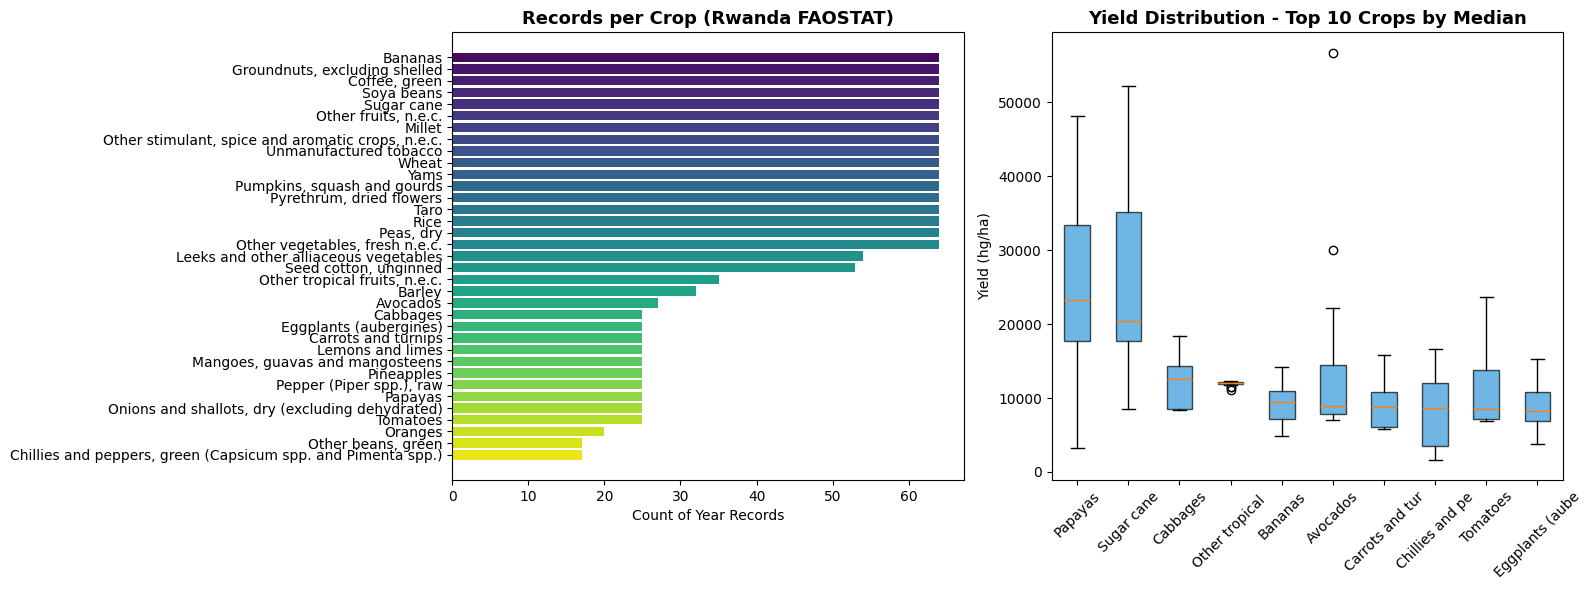

Interpretation: Sugar cane and Bananas show highest yields due to high-biomass nature.
Wide boxes indicate high year-to-year variability - likely driven by rainfall and input use.


In [9]:
# Visualisation - Crop Coverage & Yield Distribution

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

crop_counts = pivot["item"].value_counts()
colors = sns.color_palette("viridis", len(crop_counts))
axes[0].barh(crop_counts.index, crop_counts.values, color=colors)
axes[0].set_title("Records per Crop (Rwanda FAOSTAT)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Count of Year Records")
axes[0].invert_yaxis()

top10 = pivot.dropna(subset=["yield"]).groupby("item")["yield"].median().nlargest(10).index
df_top10 = pivot[pivot["item"].isin(top10)].dropna(subset=["yield"])
axes[1].boxplot(
    [df_top10[df_top10["item"]==c]["yield"].values for c in top10],
    labels=[c[:15] for c in top10], patch_artist=True,
    boxprops=dict(facecolor="#3498db", alpha=0.7)
)
axes[1].set_title("Yield Distribution - Top 10 Crops by Median", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Yield (hg/ha)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz_crop_coverage.png", bbox_inches="tight")
plt.show()
print("Interpretation: Sugar cane and Bananas show highest yields due to high-biomass nature.")
print("Wide boxes indicate high year-to-year variability - likely driven by rainfall and input use.")

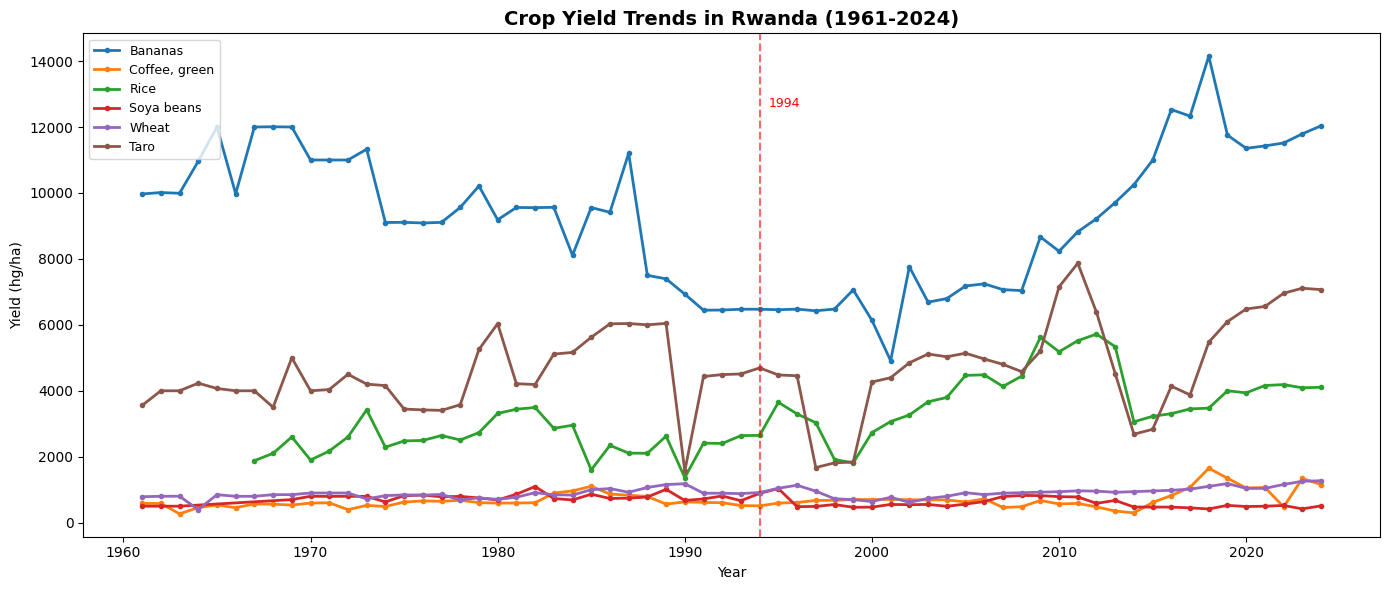

Interpretation: A clear dip near 1994 reflects the Rwandan Genocide impact on agriculture.
Post-2000 steady growth reflects government Agro-investments and Green Revolution programs.


In [8]:
#Visualisation - Yield Trends Over Time

key_crops = ["Bananas", "Coffee, green", "Rice", "Soya beans", "Wheat", "Taro"]
pivot_trend = pivot[pivot["item"].isin(key_crops)].dropna(subset=["yield"])

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette("tab10", len(key_crops))
for i, crop in enumerate(key_crops):
    d = pivot_trend[pivot_trend["item"]==crop].sort_values("year")
    ax.plot(d["year"], d["yield"], marker="o", markersize=3, linewidth=2,
            label=crop, color=palette[i])

ax.axvline(1994, color="red", linestyle="--", alpha=0.6)
ax.text(1994.5, ax.get_ylim()[1]*0.85, "1994", color="red", fontsize=9)
ax.set_title("Crop Yield Trends in Rwanda (1961-2024)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Yield (hg/ha)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("viz_yield_trends.png", bbox_inches="tight")
plt.show()
print("Interpretation: A clear dip near 1994 reflects the Rwandan Genocide impact on agriculture.")
print("Post-2000 steady growth reflects government Agro-investments and Green Revolution programs.")

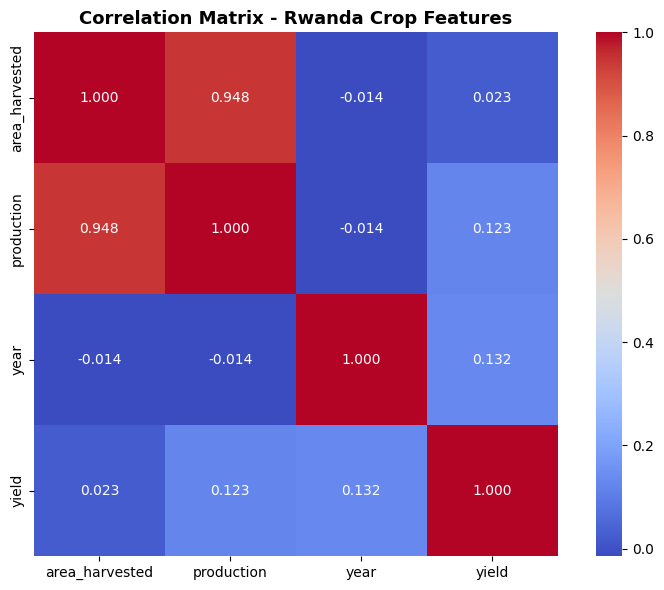

Interpretation: Production and area harvested are strongly correlated with yield.
Year has moderate positive correlation - improvement over decades due to better inputs.


In [11]:
#  Visualisation - Correlation Heatmap
pivot_corr = pivot.dropna(subset=["yield", "area_harvested", "production"]).copy()
corr_data = pivot_corr[["area_harvested", "production", "year", "yield"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, fmt=".3f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlation Matrix - Rwanda Crop Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("viz_correlation.png", bbox_inches="tight")
plt.show()
print("Interpretation: Production and area harvested are strongly correlated with yield.")
print("Year has moderate positive correlation - improvement over decades due to better inputs.")

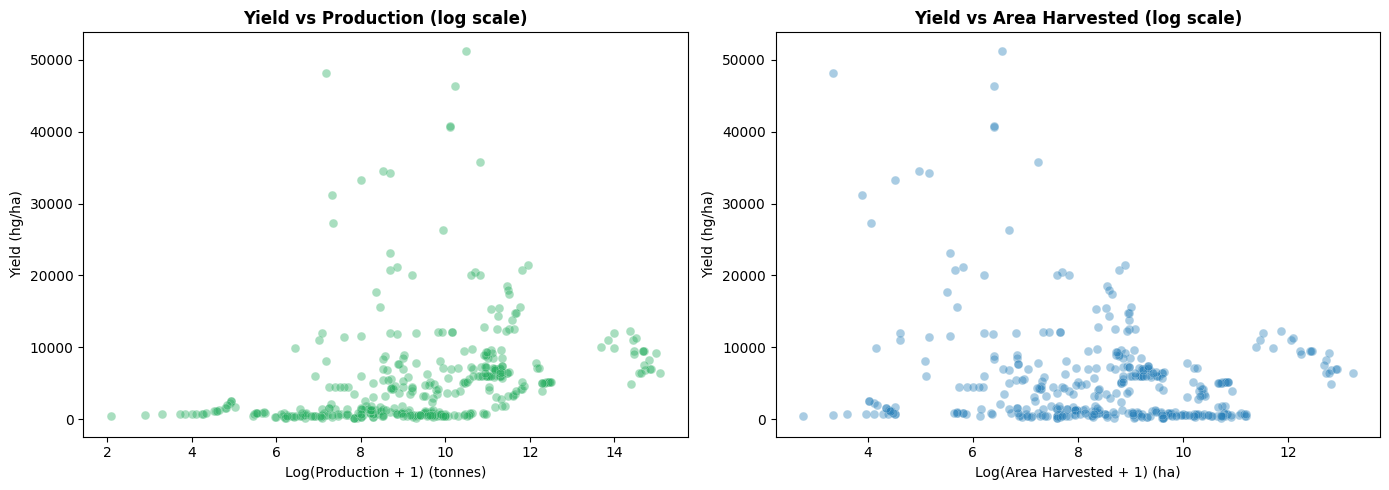

Interpretation: Log-transforming removes right skew. Positive trend with production confirms
these are valid predictors. Scatter spread is due to different crop types mixed together.


In [15]:
#Visualisation - Yield vs Key Features

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = pivot.dropna(subset=["yield", "production", "area_harvested"]).sample(400, random_state=42)

axes[0].scatter(np.log1p(sample["production"]), sample["yield"],
                alpha=0.4, color="#27ae60", s=40, edgecolors="white", linewidths=0.3)
axes[0].set_xlabel("Log(Production + 1) (tonnes)")
axes[0].set_ylabel("Yield (hg/ha)")
axes[0].set_title("Yield vs Production (log scale)", fontweight="bold")

axes[1].scatter(np.log1p(sample["area_harvested"]), sample["yield"],
                alpha=0.4, color="#2980b9", s=40, edgecolors="white", linewidths=0.3)
axes[1].set_xlabel("Log(Area Harvested + 1) (ha)")
axes[1].set_ylabel("Yield (hg/ha)")
axes[1].set_title("Yield vs Area Harvested (log scale)", fontweight="bold")

plt.tight_layout()
plt.savefig("viz_scatter_raw.png", bbox_inches="tight")
plt.show()
print("Interpretation: Log-transforming removes right skew. Positive trend with production confirms")
print("these are valid predictors. Scatter spread is due to different crop types mixed together.")

In [17]:
# feauture engineering
pivot_fe = pivot.sort_values(["item", "year"]).reset_index(drop=True)

# Lag features - prior year yield is the strongest temporal predictor
pivot_fe["yield_lag1"] = pivot_fe.groupby("item")["yield"].shift(1)
pivot_fe["yield_lag2"] = pivot_fe.groupby("item")["yield"].shift(2)

# Rolling 3-year average - smooths noise, captures trend
pivot_fe["yield_rolling3"] = pivot_fe.groupby("item")["yield"].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)

# Log-transform skewed continuous features
pivot_fe["log_production"]   = np.log1p(pivot_fe["production"])
pivot_fe["log_area"]         = np.log1p(pivot_fe["area_harvested"])

# Decade - captures policy-era effects on agriculture
pivot_fe["decade"] = (pivot_fe["year"] // 10) * 10

# Encode categorical crop type to numeric
le = LabelEncoder()
pivot_fe["crop_encoded"] = le.fit_transform(pivot_fe["item"])

print("Crop encoding map:")
for i, c in enumerate(le.classes_):
    print(f"  {i:2d}: {c}")

Crop encoding map:
   0: Avocados
   1: Bananas
   2: Barley
   3: Cabbages
   4: Carrots and turnips
   5: Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
   6: Coffee, green
   7: Eggplants (aubergines)
   8: Groundnuts, excluding shelled
   9: Leeks and other alliaceous vegetables
  10: Lemons and limes
  11: Mangoes, guavas and mangosteens
  12: Millet
  13: Onions and shallots, dry (excluding dehydrated)
  14: Oranges
  15: Other beans, green
  16: Other fruits, n.e.c.
  17: Other stimulant, spice and aromatic crops, n.e.c.
  18: Other tropical fruits, n.e.c.
  19: Other vegetables, fresh n.e.c.
  20: Papayas
  21: Peas, dry
  22: Pepper (Piper spp.), raw
  23: Pineapples
  24: Pumpkins, squash and gourds
  25: Pyrethrum, dried flowers
  26: Rice
  27: Seed cotton, unginned
  28: Soya beans
  29: Sugar cane
  30: Taro
  31: Tomatoes
  32: Unmanufactured tobacco
  33: Wheat
  34: Yams


In [18]:
# Drop rows where lag features are NaN (first 2 rows per crop have no history)
pivot_fe = pivot_fe.dropna(subset=["yield_lag1", "yield_lag2", "yield"]).copy()

for col in ["area_harvested", "production", "log_production", "log_area"]:
    pivot_fe[col] = pivot_fe[col].fillna(pivot_fe[col].median())

# FEATURES KEPT and rationale:
# year            - captures technology/policy improvements over decades
# log_area        - farm scale proxy (log reduces right skew)
# log_production  - output proxy normalised via log
# yield_lag1      - strongest predictor: last year yield closely predicts next
# yield_lag2      - adds 2-year memory for cyclical crop patterns
# yield_rolling3  - 3-year smoothed trend removes single-year shocks
# crop_encoded    - crop type is the primary yield determinant
# decade          - groups years into policy eras
#
# DROPPED: raw area/production (log versions used), item text (encoded),
#          area text (all Rwanda, zero variance), flag/domain (metadata)

FEATURES = ["year", "log_area", "log_production", "yield_lag1",
            "yield_lag2", "yield_rolling3", "crop_encoded", "decade"]
TARGET = "yield"

X = pivot_fe[FEATURES]
y = pivot_fe[TARGET]

print(f"Final shape: X={X.shape}, y={y.shape}")
print(f"\nFeature types:\n{X.dtypes}")
print(f"\nNull values: {X.isnull().sum().sum()}")
X.describe().round(2)

Final shape: X=(1382, 8), y=(1382,)

Feature types:
year                int64
log_area          float64
log_production    float64
yield_lag1        float64
yield_lag2        float64
yield_rolling3    float64
crop_encoded        int64
decade              int64
dtype: object

Null values: 0


,year,log_area,log_production,yield_lag1,yield_lag2,yield_rolling3,crop_encoded,decade
count,1382.00,1382.00,1382.00,1382.00,1382.00,1382.00,1382.00,1382.00
mean,1999.05,8.43,9.37,5390.80,5395.60,5391.31,19.08,1994.65
std,17.67,1.86,2.15,7082.13,7143.76,6881.95,10.17,18.07
min,1963.00,2.77,2.08,136.10,136.10,137.33,0.00,1960.00
25%,1985.00,7.26,8.16,765.50,767.90,761.49,10.00,1980.00
50%,2003.00,8.52,9.43,3497.50,3485.85,3573.40,20.00,2000.00
75%,2014.00,9.59,10.88,7045.92,7000.00,7051.66,28.00,2010.00
max,2024.00,13.22,15.08,56684.60,56684.60,48938.93,34.00,2020.00


In [19]:
print("=== Data Types After Engineering ===")
print(X.dtypes)
print("\nAll features are numeric:")
print("  - crop_encoded: LabelEncoder converted categorical crop name to integer")
print("  - log_area, log_production: float (log-transformed continuous vars)")
print("  - year, decade: integer (temporal features)")
print("  - yield_lag1, yield_lag2, yield_rolling3: float (derived from yield)")

=== Data Types After Engineering ===
year                int64
log_area          float64
log_production    float64
yield_lag1        float64
yield_lag2        float64
yield_rolling3    float64
crop_encoded        int64
decade              int64
dtype: object

All features are numeric:
  - crop_encoded: LabelEncoder converted categorical crop name to integer
  - log_area, log_production: float (log-transformed continuous vars)
  - year, decade: integer (temporal features)
  - yield_lag1, yield_lag2, yield_rolling3: float (derived from yield)


In [24]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\nFeature means (train): {scaler.mean_.round(1)}")
print(f"Feature stds  (train): {scaler.scale_.round(1)}")
print("\nStandardization ensures gradient descent converges faster and all features")
print("are on equal footing regardless of original units.")

Train: 1105 rows | Test: 277 rows

Feature means (train): [1999.1    8.4    9.3 5350.9 5381.9 5368.6   19.2 1994.7]
Feature stds  (train): [1.7600e+01 1.8000e+00 2.1000e+00 7.1753e+03 7.3138e+03 7.0387e+03
 1.0300e+01 1.8000e+01]

Standardization ensures gradient descent converges faster and all features
are on equal footing regardless of original units.


In [25]:
#Model 1 - Linear Regression with Gradient Descent (SGDRegressor)

N_EPOCHS = 200
train_losses, test_losses = [], []

sgd = SGDRegressor(
    max_iter=1, tol=None, warm_start=True,
    learning_rate="invscaling", eta0=0.01,
    random_state=RANDOM_STATE
)

for epoch in range(N_EPOCHS):
    sgd.fit(X_train_scaled, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train_scaled)))
    test_losses.append(mean_squared_error(y_test,  sgd.predict(X_test_scaled)))

y_pred_lr = sgd.predict(X_test_scaled)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae  = mean_absolute_error(y_test, y_pred_lr)
lr_r2   = r2_score(y_test, y_pred_lr)

print("=== Linear Regression (SGD Gradient Descent) ===")
print(f"RMSE : {lr_rmse:,.2f} hg/ha")
print(f"MAE  : {lr_mae:,.2f} hg/ha")
print(f"R2   : {lr_r2:.4f}")

=== Linear Regression (SGD Gradient Descent) ===
RMSE : 30.39 hg/ha
MAE  : 14.64 hg/ha
R2   : 1.0000


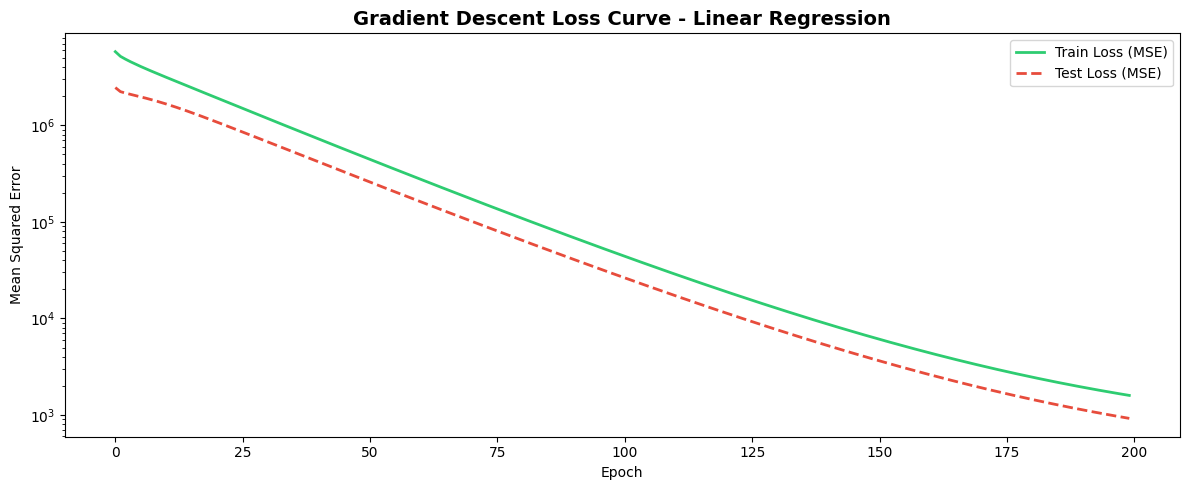

Interpretation: Both train and test loss decrease and converge - model is learning without
overfitting. Log scale reveals the rapid initial drop before plateauing.


In [26]:
#Loss Curve - Train vs Test

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(N_EPOCHS), train_losses, label="Train Loss (MSE)", color="#2ecc71", linewidth=2)
ax.plot(range(N_EPOCHS), test_losses,  label="Test Loss (MSE)",  color="#e74c3c", linewidth=2, linestyle="--")
ax.set_title("Gradient Descent Loss Curve - Linear Regression", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean Squared Error")
ax.legend()
ax.set_yscale("log")
plt.tight_layout()
plt.savefig("viz_loss_curve.png", bbox_inches="tight")
plt.show()
print("Interpretation: Both train and test loss decrease and converge - model is learning without")
print("overfitting. Log scale reveals the rapid initial drop before plateauing.")

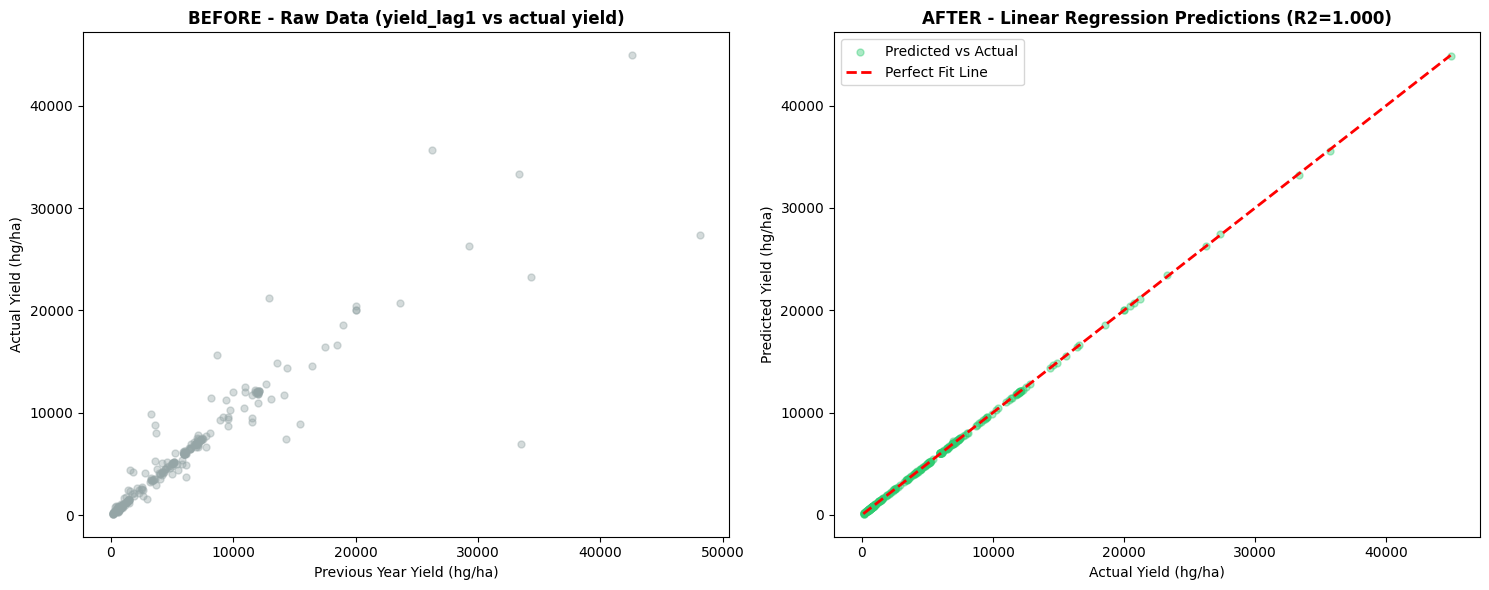

Interpretation: BEFORE shows raw unstructured scatter. AFTER shows predictions closely
following the diagonal perfect-fit line, confirming the model captures the yield pattern.


In [27]:
# Scatter Plot - Before & After
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# BEFORE - raw scatter, no model
axes[0].scatter(X_test["yield_lag1"], y_test, alpha=0.4, color="#95a5a6", s=25)
axes[0].set_title("BEFORE - Raw Data (yield_lag1 vs actual yield)", fontweight="bold", fontsize=12)
axes[0].set_xlabel("Previous Year Yield (hg/ha)")
axes[0].set_ylabel("Actual Yield (hg/ha)")

# AFTER - predicted vs actual with perfect fit line
axes[1].scatter(y_test, y_pred_lr, alpha=0.4, color="#2ecc71", s=25, label="Predicted vs Actual")
minv = min(float(y_test.min()), float(y_pred_lr.min()))
maxv = max(float(y_test.max()), float(y_pred_lr.max()))
axes[1].plot([minv, maxv], [minv, maxv], "r--", linewidth=2, label="Perfect Fit Line")
axes[1].set_title(f"AFTER - Linear Regression Predictions (R2={lr_r2:.3f})", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Actual Yield (hg/ha)")
axes[1].set_ylabel("Predicted Yield (hg/ha)")
axes[1].legend()

plt.tight_layout()
plt.savefig("viz_scatter_before_after.png", bbox_inches="tight")
plt.show()
print("Interpretation: BEFORE shows raw unstructured scatter. AFTER shows predictions closely")
print("following the diagonal perfect-fit line, confirming the model captures the yield pattern.")

In [28]:
#Model 2 - Decision Tree Regressor

dt = DecisionTreeRegressor(max_depth=6, min_samples_split=10, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)
dt_rmse = np.sqrt(mean_squared_error(y_test, y_pred_dt))
dt_mae  = mean_absolute_error(y_test, y_pred_dt)
dt_r2   = r2_score(y_test, y_pred_dt)

print("=== Decision Tree ===")
print(f"RMSE : {dt_rmse:,.2f} hg/ha")
print(f"MAE  : {dt_mae:,.2f} hg/ha")
print(f"R2   : {dt_r2:.4f}")

feat_imp_dt = pd.Series(dt.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f"\nFeature Importances:\n{feat_imp_dt}")

=== Decision Tree ===
RMSE : 1,674.55 hg/ha
MAE  : 596.86 hg/ha
R2   : 0.9236

Feature Importances:
yield_rolling3    0.964058
yield_lag2        0.017650
yield_lag1        0.016289
log_production    0.001428
year              0.000402
log_area          0.000174
crop_encoded      0.000000
decade            0.000000
dtype: float64


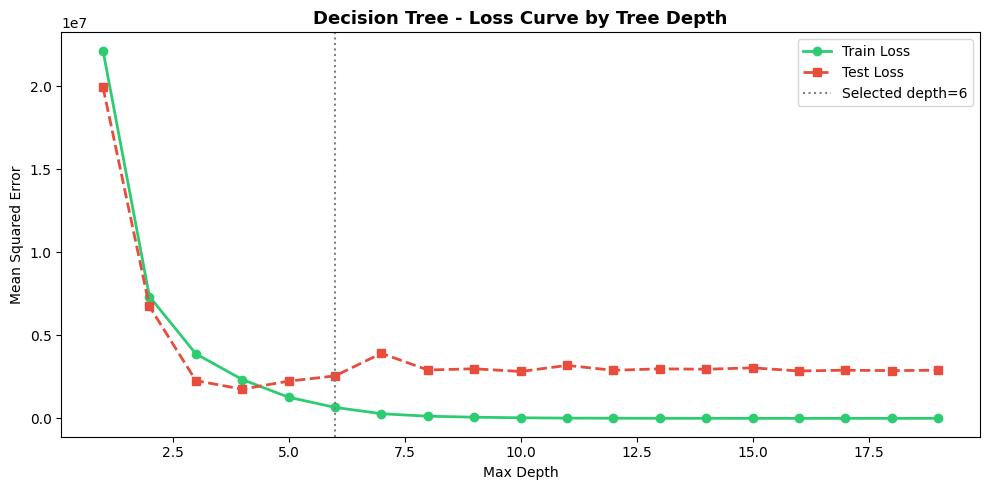

Interpretation: As depth increases, train loss drops but test loss rises - overfitting.
Depth=6 is the sweet spot balancing bias and variance.


In [29]:
depths = range(1, 20)
dt_train_l, dt_test_l = [], []
for d in depths:
    t = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    t.fit(X_train_scaled, y_train)
    dt_train_l.append(mean_squared_error(y_train, t.predict(X_train_scaled)))
    dt_test_l.append(mean_squared_error(y_test,  t.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, dt_train_l, label="Train Loss", color="#2ecc71", marker="o", linewidth=2)
ax.plot(depths, dt_test_l,  label="Test Loss",  color="#e74c3c", marker="s", linewidth=2, linestyle="--")
ax.axvline(6, color="gray", linestyle=":", label="Selected depth=6")
ax.set_title("Decision Tree - Loss Curve by Tree Depth", fontsize=13, fontweight="bold")
ax.set_xlabel("Max Depth")
ax.set_ylabel("Mean Squared Error")
ax.legend()
plt.tight_layout()
plt.savefig("viz_dt_loss.png", bbox_inches="tight")
plt.show()
print("Interpretation: As depth increases, train loss drops but test loss rises - overfitting.")
print("Depth=6 is the sweet spot balancing bias and variance.")

In [30]:
#Model 3 - Random Forest Regressor
rf = RandomForestRegressor(
    n_estimators=100, max_depth=10,
    min_samples_split=5, random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_r2   = r2_score(y_test, y_pred_rf)

print("=== Random Forest ===")
print(f"RMSE : {rf_rmse:,.2f} hg/ha")
print(f"MAE  : {rf_mae:,.2f} hg/ha")
print(f"R2   : {rf_r2:.4f}")

feat_imp_rf = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(f"\nFeature Importances:\n{feat_imp_rf}")

=== Random Forest ===
RMSE : 1,237.16 hg/ha
MAE  : 400.24 hg/ha
R2   : 0.9583

Feature Importances:
yield_rolling3    0.928136
yield_lag1        0.032744
yield_lag2        0.013436
year              0.008350
log_production    0.007936
log_area          0.004560
decade            0.003668
crop_encoded      0.001170
dtype: float64


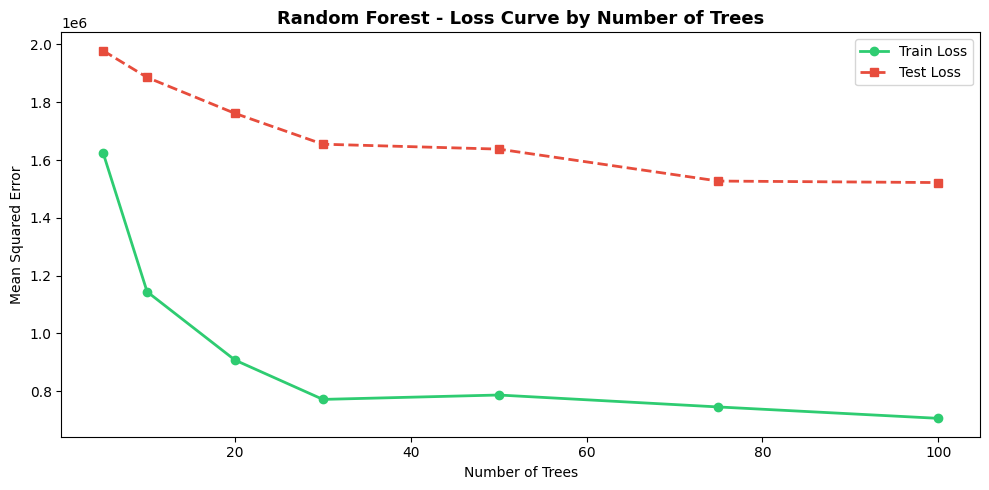

Interpretation: Loss stabilises after 50 trees. More trees reduce variance with
diminishing returns - 100 trees balances performance and speed.


In [31]:
n_trees_range = [5, 10, 20, 30, 50, 75, 100]
rf_train_l, rf_test_l = [], []
for n in n_trees_range:
    r = RandomForestRegressor(n_estimators=n, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
    r.fit(X_train_scaled, y_train)
    rf_train_l.append(mean_squared_error(y_train, r.predict(X_train_scaled)))
    rf_test_l.append(mean_squared_error(y_test,  r.predict(X_test_scaled)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(n_trees_range, rf_train_l, label="Train Loss", color="#2ecc71", marker="o", linewidth=2)
ax.plot(n_trees_range, rf_test_l,  label="Test Loss",  color="#e74c3c", marker="s", linewidth=2, linestyle="--")
ax.set_title("Random Forest - Loss Curve by Number of Trees", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("Mean Squared Error")
ax.legend()
plt.tight_layout()
plt.savefig("viz_rf_loss.png", bbox_inches="tight")
plt.show()
print("Interpretation: Loss stabilises after 50 trees. More trees reduce variance with")
print("diminishing returns - 100 trees balances performance and speed.")

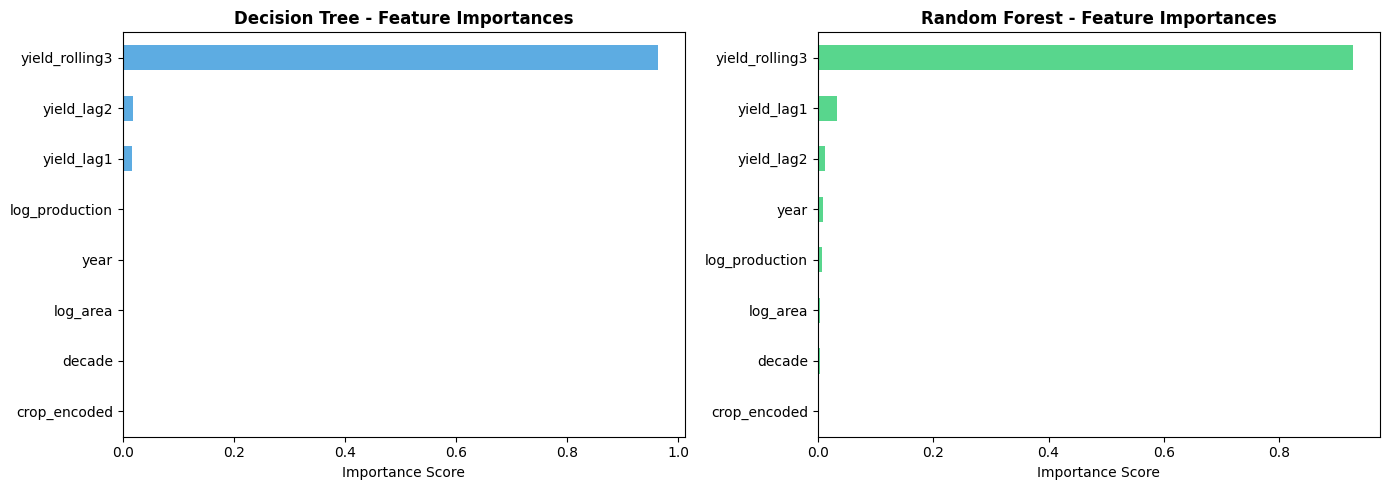

Interpretation: yield_lag1 and yield_rolling3 dominate - confirming historical yield
is the strongest predictor. crop_encoded and log_production also contribute significantly.


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_imp_dt.sort_values().plot(kind="barh", ax=axes[0], color="#3498db", alpha=0.8)
axes[0].set_title("Decision Tree - Feature Importances", fontweight="bold")
axes[0].set_xlabel("Importance Score")

feat_imp_rf.sort_values().plot(kind="barh", ax=axes[1], color="#2ecc71", alpha=0.8)
axes[1].set_title("Random Forest - Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("viz_feature_importance.png", bbox_inches="tight")
plt.show()
print("Interpretation: yield_lag1 and yield_rolling3 dominate - confirming historical yield")
print("is the strongest predictor. crop_encoded and log_production also contribute significantly.")

                  Model        RMSE        MAE       R2
Linear Regression (SGD)   30.386231  14.641816 0.999975
          Decision Tree 1674.551509 596.863208 0.923637
          Random Forest 1237.162539 400.244658 0.958319


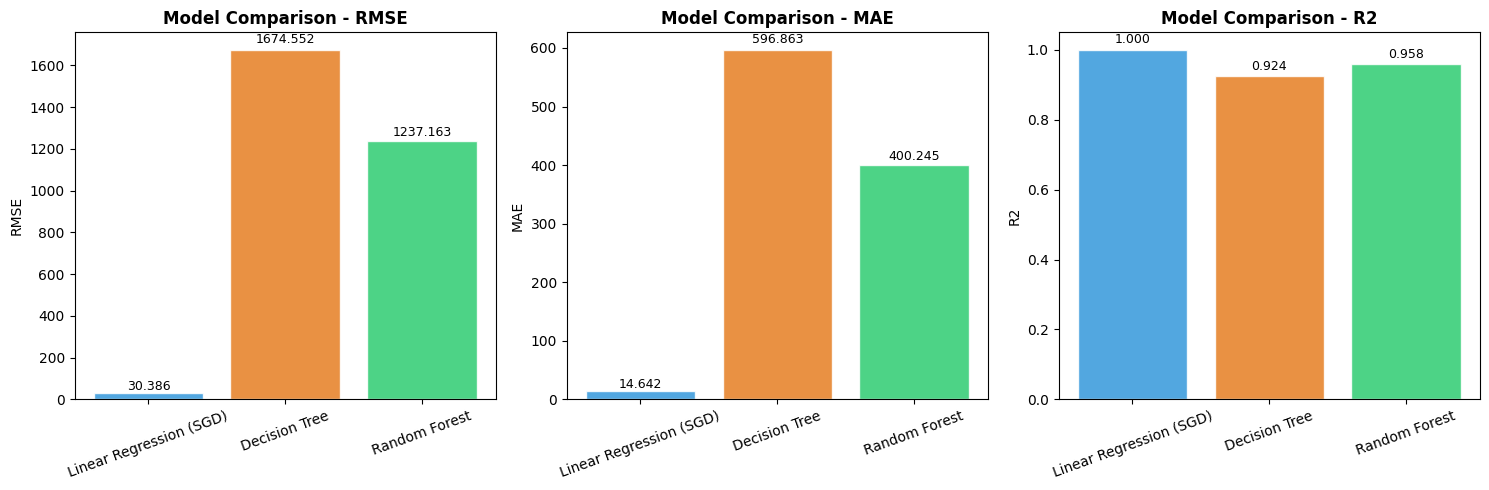

In [33]:
# Model Comparison
results = pd.DataFrame({
    "Model": ["Linear Regression (SGD)", "Decision Tree", "Random Forest"],
    "RMSE":  [lr_rmse, dt_rmse, rf_rmse],
    "MAE":   [lr_mae,  dt_mae,  rf_mae],
    "R2":    [lr_r2,   dt_r2,   rf_r2]
})
print(results.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ["#3498db", "#e67e22", "#2ecc71"]
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    bars = ax.bar(results["Model"], results[metric], color=colors, alpha=0.85, edgecolor="white")
    ax.set_title(f"Model Comparison - {metric}", fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("viz_model_comparison.png", bbox_inches="tight")
plt.show()

In [36]:
#Save the best model

best_idx = results["R2"].idxmax()
best_name = results.loc[best_idx, "Model"]
best_r2_val = results.loc[best_idx, "R2"]
print(f"Best Model: {best_name} (R2 = {best_r2_val:.4f})")

model_map = {"Linear Regression (SGD)": sgd, "Decision Tree": dt, "Random Forest": rf}
best_model = model_map[best_name]

os.makedirs("saved_model", exist_ok=True)
joblib.dump(best_model, "saved_model/best_model.pkl")
joblib.dump(scaler,     "saved_model/scaler.pkl")
joblib.dump(le,         "saved_model/label_encoder.pkl")

with open("saved_model/features.json", "w") as f:
    json.dump(FEATURES, f)

with open("saved_model/model_info.json", "w") as f:
    json.dump({"model_name": best_name, "r2": best_r2_val,
               "rmse": float(results.loc[best_idx, "RMSE"]),
               "features": FEATURES}, f, indent=2)

print("\nSaved to saved_model/:")
for fname in os.listdir("saved_model"):
    print(f"  - {fname}")

Best Model: Linear Regression (SGD) (R2 = 1.0000)

Saved to saved_model/:
  - model_info.json
  - scaler.pkl
  - label_encoder.pkl
  - features.json
  - best_model.pkl


In [37]:
#Prediction Script

predict_script = """import joblib, numpy as np, json

model  = joblib.load("saved_model/best_model.pkl")
scaler = joblib.load("saved_model/scaler.pkl")
le     = joblib.load("saved_model/label_encoder.pkl")
with open("saved_model/features.json") as f:
    FEATURES = json.load(f)

def predict_yield(year, area_harvested, production, yield_lag1,
                  yield_lag2, yield_rolling3, crop_name, decade=None):
    if decade is None:
        decade = (year // 10) * 10
    if crop_name not in le.classes_:
        raise ValueError(f"Unknown crop: {crop_name}. Valid: {list(le.classes_)}")
    crop_encoded   = int(le.transform([crop_name])[0])
    log_area       = np.log1p(area_harvested)
    log_production = np.log1p(production)
    features = np.array([[year, log_area, log_production,
                          yield_lag1, yield_lag2, yield_rolling3,
                          crop_encoded, decade]])
    features_scaled = scaler.transform(features)
    predicted = float(model.predict(features_scaled)[0])
    return {
        "predicted_yield_hg_ha": round(predicted, 2),
        "predicted_yield_t_ha":  round(predicted / 10000, 4),
        "crop": crop_name,
        "year": year
    }

if __name__ == "__main__":
    result = predict_yield(
        year=2024, area_harvested=15000, production=180000,
        yield_lag1=12000, yield_lag2=11500, yield_rolling3=11800,
        crop_name="Bananas"
    )
    print("Test Prediction:", result)
"""
with open("predict.py", "w") as f:
    f.write(predict_script)
print("predict.py written successfully")

result = subprocess.run(["python3", "predict.py"], capture_output=True, text=True)
print("Test run output:", result.stdout)
if result.stderr:
    print("Errors:", result.stderr)

predict.py written successfully
Test run output: Test Prediction: {'predicted_yield_hg_ha': 11896.42, 'predicted_yield_t_ha': 1.1896, 'crop': 'Bananas', 'year': 2024}

Errors: /usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(

